## Exploring the Dataset
This notebook explores the Touch-Ex dataset by using the developed pipeline functions found in the data directory.

In [1]:
# Allow imports from the parent directory
import sys
import os

module_path = os.path.abspath(os.path.join(".."))
sys.path.append(module_path)

In [2]:
# Imports
import torchvision
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from data.dataset import TouchExDataset
import data.utils as utils
import json

In [3]:
# Get default data config from json file
with open("../configs/default_data_config.json", "r", encoding="utf-8") as f:
    data_config = json.load(f)
data_config

{'random_state': 129,
 'split_size': 0.3,
 'stratify_label': 'object',
 'filtered_force_level': None,
 'filtered_motion': None,
 'transform_name': 'pad_224',
 'bg_path': 'data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': 'configs/norm_cache.json',
 'batch_size': 64,
 'num_workers': 4,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

In [4]:
# Make some changes to the data_config based on directory location of this notebook
data_config["bg_path"] = "../data/baseline.jpg"
data_config["norm_cache_path"] = "../configs/norm_cache.json"

### Load Data

In [23]:
# Load the dataset into DataFrames
dfs = utils.load_touch_ex_dataset()

In [24]:
# Extract the training and test_unseen DataFrames from the dictionary
train_df = dfs["train"]
test_unseen_df = dfs["test_unseen"]

In [25]:
# View the first few rows of the training DataFrame
train_df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.016114,0.014450,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0001,football_panels_force1_interaction0001
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.020948,0.018785,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0002,football_panels_force1_interaction0001
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,sliding,0.016114,0.014450,medium,pu leather,"A firm, compressible spherical PU leather surf...",0001,0003,football_panels_force1_interaction0001


In [26]:
# View the first few rows of the test_unseen DataFrame
test_unseen_df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.045118,0.040459,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0001,beaker_body_force1_interaction0001
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.033838,0.030345,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0002,beaker_body_force1_interaction0001
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.029004,0.026010,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0003,beaker_body_force1_interaction0001


In [27]:
# Add new columns to test_unseen_df for expected labels
test_unseen_df = utils.add_expected_labels(test_unseen_df)
test_unseen_df.head(3)

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id,expected_object,expected_object_region
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.045118,0.040459,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0001,beaker_body_force1_interaction0001,mug,mug_body
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.033838,0.030345,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0002,beaker_body_force1_interaction0001,mug,mug_body
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,beaker,body,beaker_body,1,sliding,0.029004,0.026010,medium-hard,plastic,A thin-walled plastic body with a tapered cyli...,0001,0003,beaker_body_force1_interaction0001,mug,mug_body


Let's try spliting the main training set into train/val/test splits.

In [28]:
train_df = train_df[train_df["motion"] == "rotation"]

In [29]:
train_df

,image,object,region,object_region,force_level,motion,fsr_voltage,force_n,hardness,material,description,interaction_num,frame_num,interaction_id
720,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,rotation,0.016919,0.015172,medium,pu leather,"A firm, compressible spherical PU leather surf...",0007,0001,football_panels_force1_interaction0007
721,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,rotation,0.016114,0.014450,medium,pu leather,"A firm, compressible spherical PU leather surf...",0007,0002,football_panels_force1_interaction0007
722,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,rotation,0.015308,0.013727,medium,pu leather,"A firm, compressible spherical PU leather surf...",0007,0003,football_panels_force1_interaction0007
723,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,rotation,0.016919,0.015172,medium,pu leather,"A firm, compressible spherical PU leather surf...",0007,0004,football_panels_force1_interaction0007
724,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,football,panels,football_panels,1,rotation,0.012891,0.011560,medium,pu leather,"A firm, compressible spherical PU leather surf...",0007,0005,football_panels_force1_interaction0007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120955,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,wooden_spoon,head,wooden_spoon_head,3,rotation,3.106638,8.356141,hard,wood,A rounded form made of finished wood with a su...,0012,0116,wooden_spoon_head_force3_interaction0012
120956,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,wooden_spoon,head,wooden_spoon_head,3,rotation,3.134836,14.715000,hard,wood,A rounded form made of finished wood with a su...,0012,0117,wooden_spoon_head_force3_interaction0012
120957,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,wooden_spoon,head,wooden_spoon_head,3,rotation,3.101804,8.041396,hard,wood,A rounded form made of finished wood with a su...,0012,0118,wooden_spoon_head_force3_interaction0012
120958,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,wooden_spoon,head,wooden_spoon_head,3,rotation,3.125974,9.747155,hard,wood,A rounded form made of finished wood with a su...,0012,0119,wooden_spoon_head_force3_interaction0012


In [30]:
# Split the dataset into training, validation, and test sets
# The split is done by interaction to ensure that all samples from a given interaction are in the same set to avoid data leakage  # noqa: E501
train_df, val_df, test_df = utils.split_by_interaction(
    train_df,
    split_size=data_config["split_size"],
    stratify_label=data_config["stratify_label"],
    random_state=data_config["random_state"],
)

Dataframe split into following sizes:
Train: 42240, Val: 9120, Test: 9120


In [42]:
# Get label mappings from the training set
train_label_mappings = utils.get_label_mappings(train_df)
# Get label mappings from the unseen test set
test_unseen_label_mappings = utils.get_label_mappings(test_unseen_df)

In [45]:
# Extract the idx2label mappings for training and unseen test sets
# This is so we can use them later to convert model predictions back to readable labels
train_idx2label = train_label_mappings["idx2label"]
test_unseen_idx2label = test_unseen_label_mappings["idx2label"]

In [ ]:
# View the mapping for the training set "object" label
train_idx2label["object"]

{0: 'football',
 1: 'hammer',
 2: 'mug',
 3: 'plastic_bottle',
 4: 'scissors',
 5: 'sponge_scourer',
 6: 'tea_towel',
 7: 'tennis_ball',
 8: 'tin_beans',
 9: 'toilet_roll',
 10: 'toothbrush',
 11: 'tube_pringles',
 12: 'tv_remote',
 13: 'wooden_spoon'}

In [48]:
# View the mapping for the test_unseen set "object" label
test_unseen_idx2label["object"]

{0: 'beaker',
 1: 'dish_brush',
 2: 'media_remote',
 3: 'microfibre_cloth',
 4: 'patterned_mug',
 5: 'rubber_ball',
 6: 'small_scissors',
 7: 'table_knife',
 8: 'tin_peas'}

In [49]:
# Get normalisation statistics from the training set for this dataset configuration
# If a cache file exists, it will be loaded instead of recomputing the statistics
norm_stats = utils.get_norm_stats(train_df, data_config)
norm_stats

Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.


(tensor([ 0.0023, -0.0062,  0.0025]), tensor([0.0344, 0.0268, 0.0282]))

### TouchFL Dataset

In [ ]:
# Create dataset objects for the training set using the TouchExDataset class
train_dataset = TouchExDataset(
    train_df,
    train_label_mappings,
    test_unseen_label_mappings,
    data_config["transform_name"],
    norm_stats,
    data_config["bg_path"],
    test_unseen_df=False,
)

In [13]:
# Get a sample from the training dataset and display its keys
sample = train_dataset[0]
sample.keys()

dict_keys(['image', 'force_n', 'fsr_voltage', 'description', 'interaction_num', 'frame_num', 'interaction_id', 'object', 'object_region', 'force_level', 'hardness', 'material'])

In [14]:
# Display the shapes of the image tensor and the values of the other features in the sample
for k, v in sample.items():
    print(f"{k}: {v.shape if k == 'image' else v}")

image: torch.Size([3, 224, 224])
force_n: 0.013392293825745583
fsr_voltage: 0.0161135271191597
description: An elongated, solid rubber-coated gripping area featuring small, evenly spaced circular dimples that provide a repeating texture.
interaction_num: 0001
frame_num: 0001
interaction_id: hammer_handle_force1_interaction0001
object: 0
object_region: 0
force_level: 0
hardness: 0
material: 0


In [15]:
# Use the idx2label mappings to convert the class indexes back to readable class names
for k in idx2label.keys():
    mapping = idx2label[k]
    class_idx = sample[k].item()
    class_name = mapping[class_idx]
    print(f"{k}: {class_name} (class index: {class_idx})")

object: hammer (class index: 0)
object_region: hammer_handle (class index: 0)
force_level: 1 (class index: 0)
hardness: medium-hard (class index: 0)
material: rubber (class index: 0)


### Data Loader and Visualisation

In [16]:
# Create a small batch size dataloader for visualisation
viz_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
data = next(iter(viz_dataloader))

In [17]:
# Extract the inputs and object labels from the batch of data
inputs, labels = data["image"], data["object"]
# Create a grid of the input images for visualisation using torchvision's make_grid function
grid = torchvision.utils.make_grid(inputs)

/tmp/ipykernel_21546/2475835971.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  input = std * input + mean


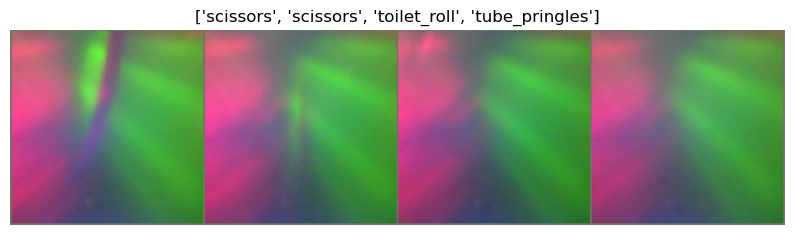

In [18]:
# Convert grid image tensor to a numpy array and transpose it to (H, W, C) format
input = grid.numpy().transpose((1, 2, 0))
# Un-normalise the image for correct display
mean = norm_stats[0]
std = norm_stats[1]
input = std * input + mean
input = np.clip(input, 0, 1)
# Display the image using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(input)
plt.title([idx2label["object"][idx.item()] for idx in labels])
plt.axis("off")
plt.show()